# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/flyrank-bih/flyrank-ml-internship-starter/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

**Reason codes, each a plain check on Feb-only signals, plus the model's own score:**
- `model_decline_risk` — RF probability ≥ 0.6.
- `low_ctr_visible_page` — CTR below its own position tier's average AND ranked top-20.
- `low_engagement_visible_page` — engagement rate below the panel median, only on pages with
  real GA4 session data (`had_ga4_feb`); never flagged on missing data.
- `high_volume_opportunity` — top-quartile impressions, not already flagged as decline risk.

**Action mapping:** decline risk + low CTR → `refresh_and_review_ctr`; decline risk + low
engagement (and not already caught by the CTR rule) → `refresh_and_review_engagement`; decline
risk alone → `refresh`; high-volume opportunity without decline risk → `expand_and_refresh`;
nothing flagged → `monitor`.

**Score:** RF probability. Held-out Precision@50 was 0.900 under client-grouped validation
(Week 6/7); this notebook's model is refit on the full eligible panel for the deployed queue.

In [20]:
import duckdb
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from google.colab import userdata
import json
from sklearn.ensemble import RandomForestClassifier
con = duckdb.connect()
con.execute("CREATE SECRET (TYPE huggingface, TOKEN '')")  # accept the gate in-browser first, then paste a READ token
rel = "hf://datasets/FlyRank/internship-warehouse"
con.sql(f"SELECT COUNT(*) FROM read_parquet('{rel}/fact_content_daily_performance/**/*.parquet')")


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

┌──────────────┐
│ count_star() │
│    int64     │
├──────────────┤
│     78835655 │
└──────────────┘

In [21]:
import os, sys, subprocess, json
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/flyrank-bih/flyrank-ml-internship-starter"
REPO_DIR = "flyrank-ml-internship-starter"

if IN_COLAB:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    os.chdir(REPO_DIR)
else:
    while not os.path.isdir("data/raw") and os.getcwd() != "/":
        os.chdir("..")

print("Working dir:", os.getcwd())
assert os.path.exists("data/raw/content_refresh_anonymized.csv"), "Not at repo root -- fix before continuing"
os.makedirs("work/outputs/charts", exist_ok=True)
print("Repo root confirmed. work/outputs/ ready.")





Working dir: /content/flyrank-ml-internship-starter/flyrank-ml-internship-starter
Repo root confirmed. work/outputs/ ready.


In [22]:
panel = con.sql(f"""
    WITH feb AS (
        SELECT client_hash_id, content_hash_id,
               AVG(gsc_avg_position)      AS avg_position_feb,
               SUM(gsc_impressions)       AS impressions_feb,
               SUM(gsc_clicks)            AS clicks_feb,
               SUM(ga4_sessions)          AS ga4_sessions_feb,
               SUM(ga4_engaged_sessions)  AS ga4_engaged_sessions_feb,
               SUM(ga4_pageviews)         AS ga4_pageviews_feb,
               SUM(scroll_events)         AS scroll_events_feb,
               SUM(sessions_ai)           AS sessions_ai_feb
        FROM read_parquet('{fact_table}') WHERE month = '{FEATURE_MONTH}'
        GROUP BY client_hash_id, content_hash_id
    ), mar AS (
        SELECT client_hash_id, content_hash_id, SUM(gsc_clicks) AS clicks_mar
        FROM read_parquet('{fact_table}') WHERE month = '{LABEL_MONTH}'
        GROUP BY client_hash_id, content_hash_id
    )
    SELECT feb.*, mar.clicks_mar
    FROM feb JOIN mar USING (client_hash_id, content_hash_id)
    WHERE feb.clicks_feb > 0
""").df()

panel["is_declining"] = (panel["clicks_mar"] < 0.8 * panel["clicks_feb"]).astype(int)
panel["ctr_feb"] = panel["clicks_feb"] / panel["impressions_feb"].replace(0, np.nan)
panel["had_ga4_feb"] = panel["ga4_sessions_feb"] > 0
panel["engagement_rate_feb"] = np.where(panel["had_ga4_feb"], panel["ga4_engaged_sessions_feb"] / panel["ga4_sessions_feb"], 0.0)
panel["scroll_rate_feb"] = np.where(panel["ga4_pageviews_feb"] > 0, panel["scroll_events_feb"] / panel["ga4_pageviews_feb"], 0.0)
panel["ai_referral_share_feb"] = np.where(panel["had_ga4_feb"], panel["sessions_ai_feb"] / panel["ga4_sessions_feb"], 0.0)
numeric_cols = panel.select_dtypes(include=[np.number]).columns
panel[numeric_cols] = panel[numeric_cols].fillna(0)

def position_tier(p):
    if p <= 3: return "top_3"
    if p <= 10: return "page_1"
    if p <= 20: return "page_2"
    return "deep"
panel["position_tier"] = panel["avg_position_feb"].apply(position_tier)

feature_cols = ["avg_position_feb", "impressions_feb", "ctr_feb", "engagement_rate_feb", "scroll_rate_feb", "ai_referral_share_feb"]
rf_final = RandomForestClassifier(n_estimators=200, max_depth=6, class_weight="balanced", random_state=RANDOM_STATE)
rf_final.fit(panel[feature_cols], panel["is_declining"])
panel["rf_score"] = rf_final.predict_proba(panel[feature_cols])[:, 1]

tier_ctr_avg = panel.groupby("position_tier")["ctr_feb"].transform("mean")
engagement_median = panel.loc[panel["had_ga4_feb"], "engagement_rate_feb"].median()
volume_q4 = panel["impressions_feb"].quantile(0.75)

panel["model_decline_risk"] = panel["rf_score"] >= 0.6
panel["low_ctr_visible_page"] = (panel["ctr_feb"] < tier_ctr_avg) & (panel["avg_position_feb"] <= 20)
panel["low_engagement_visible_page"] = panel["had_ga4_feb"] & (panel["engagement_rate_feb"] < engagement_median)
panel["high_volume_opportunity"] = (panel["impressions_feb"] >= volume_q4) & ~panel["model_decline_risk"]

def assign_action(row):
    codes = []
    if row["model_decline_risk"]: codes.append("model_decline_risk")
    if row["low_ctr_visible_page"]: codes.append("low_ctr_visible_page")
    if row["low_engagement_visible_page"]: codes.append("low_engagement_visible_page")
    if row["high_volume_opportunity"]: codes.append("high_volume_opportunity")
    if row["model_decline_risk"] and row["low_ctr_visible_page"]:
        action = "refresh_and_review_ctr"
    elif row["model_decline_risk"] and row["low_engagement_visible_page"]:
        action = "refresh_and_review_engagement"
    elif row["model_decline_risk"]:
        action = "refresh"
    elif row["high_volume_opportunity"]:
        action = "expand_and_refresh"
    else:
        action = "monitor"
    return pd.Series({"action": action, "reason_codes": ",".join(codes) if codes else "none"})

panel[["action", "reason_codes"]] = panel.apply(assign_action, axis=1)
panel["confidence"] = np.where(panel["had_ga4_feb"] & (panel["position_tier"] != "no_position"), "high",
                        np.where(panel["had_ga4_feb"] | (panel["position_tier"] != "no_position"), "medium", "low"))

queue = panel.sort_values("rf_score", ascending=False).reset_index(drop=True)
print("Action mix:")
print(queue["action"].value_counts())
print(f"\nHeld-out Precision@50 this queue is built on (Week 6/7, client-grouped): 0.900")
queue[["client_hash_id", "content_hash_id", "rf_score", "action", "reason_codes", "confidence"]].head(10)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Action mix:
action
monitor                   30236
expand_and_refresh        13435
refresh                    6071
refresh_and_review_ctr     3996
Name: count, dtype: int64

Held-out Precision@50 this queue is built on (Week 6/7, client-grouped): 0.900


,client_hash_id,content_hash_id,rf_score,action,reason_codes,confidence
0,client_f623b01661d4bfe4,content_71ac20acaf910aac,0.944740,refresh,model_decline_risk,high
1,client_08a6a72ff48e62c0,content_679e51f82135fad6,0.943214,refresh,model_decline_risk,medium
2,client_3ffa76342f366962,content_21e80ef015b2839b,0.943214,refresh,model_decline_risk,medium
3,client_3ffa76342f366962,content_602036e138bb815e,0.943214,refresh,model_decline_risk,medium
4,client_f623b01661d4bfe4,content_148ea146703f43f7,0.932967,refresh,model_decline_risk,high
5,client_3f0ce4d44fe94f3d,content_767c793957ee4c79,0.932800,refresh,model_decline_risk,medium
6,client_3f0ce4d44fe94f3d,content_3f230cbfac13abd8,0.932800,refresh,model_decline_risk,medium
7,client_3ffa76342f366962,content_4a1c964945614571,0.931886,refresh,model_decline_risk,medium
8,client_3f0ce4d44fe94f3d,content_8e449ac0c94b13bf,0.931753,refresh,model_decline_risk,medium
9,client_3ffa76342f366962,content_971172562850e447,0.931740,refresh,model_decline_risk,medium


## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

**Who uses this:** a content reviewer with limited weekly capacity, as a triage aid — not an
automated action system. **What for:** deciding which pages to open first.

**Where it stops being valid:**
- Trained and labeled on a single Feb→March window — no evidence it holds for other months
  or seasonal content.
- `low`-confidence rows shouldn't be trusted at the same level as `high`-confidence rows.
- The label is a proxy (clicks dropping ≥20% month over month), not a verified business
  outcome.
- Only tested on clients with full February history; a brand-new client has no equivalent
  validation.

In [23]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
# Back the limits claims above with real numbers from this panel
print(f"Panel rows: {len(panel)}")
print(f"Confidence mix: {panel['confidence'].value_counts(normalize=True).round(3).to_dict()}")
print(f"GA4 coverage rate (had_ga4_feb): {panel['had_ga4_feb'].mean():.1%}")
print(f"Position coverage rate: {(panel['position_tier'] != 'no_position').mean():.1%}")
print(f"\nMonths this panel spans: {FEATURE_MONTH} (features) -> {LABEL_MONTH} (label) only")
print("No other month combination has been validated in this notebook.")

Panel rows: 53738
Confidence mix: {'medium': 0.71, 'high': 0.29}
GA4 coverage rate (had_ga4_feb): 29.0%
Position coverage rate: 100.0%

Months this panel spans: 2026-02 (features) -> 2026-03 (label) only
No other month combination has been validated in this notebook.


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

**Before acting on any flagged page, a reviewer checks:** the page still exists and isn't
already scheduled for removal/redirect; the decline isn't explained by something outside
content quality (seasonality, a known site migration, a tracking outage); `confidence` is
`high` or `medium`, not `low`; the reason code actually matches what the reviewer sees on
the page.

**Never automated — hard no-go list:**
- No page is edited, unpublished, or redirected without a human opening it first.
- No client is notified or billed based on this queue directly.
- No `low`-confidence row triggers an action on its own — review only, no exceptions.
- No single feature threshold triggers an action alone, outside the full rule logic above.
- The model's score is never treated as certainty — it's a sort order, not a verdict.

In [24]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
low_conf_actionable = queue[(queue["confidence"] == "low") & (queue["action"] != "monitor")]
print(f"Low-confidence rows with a non-monitor action (must be 0): {len(low_conf_actionable)}")

actionable_no_reason = queue[(queue["action"] != "monitor") & (queue["reason_codes"] == "none")]
print(f"Actionable rows with no reason code (must be 0): {len(actionable_no_reason)}")

print("\nConfidence mix by action:")
print(pd.crosstab(queue["action"], queue["confidence"]))

raw_engagement_flags = panel["low_engagement_visible_page"].sum()
raw_ctr_flags = panel["low_ctr_visible_page"].sum()
both_flags = (panel["low_engagement_visible_page"] & panel["low_ctr_visible_page"]).sum()
decline_and_engagement_only = panel[panel["model_decline_risk"] & panel["low_engagement_visible_page"] & ~panel["low_ctr_visible_page"]]
print(f"\nRows with low_engagement_visible_page flag: {raw_engagement_flags} "
      f"(only possible on the {panel['had_ga4_feb'].mean():.0%} of rows with real GA4 data)")
print(f"Rows with low_ctr_visible_page flag: {raw_ctr_flags}")
print(f"Rows with BOTH flags (ctr flag wins in the if/elif order): {both_flags}")
print(f"Rows that would get refresh_and_review_engagement: {len(decline_and_engagement_only)}")

Low-confidence rows with a non-monitor action (must be 0): 0
Actionable rows with no reason code (must be 0): 0

Confidence mix by action:
confidence              high  medium
action                              
expand_and_refresh      4537    8898
monitor                 8581   21655
refresh                 1507    4564
refresh_and_review_ctr   951    3045

Rows with low_engagement_visible_page flag: 0 (only possible on the 29% of rows with real GA4 data)
Rows with low_ctr_visible_page flag: 42878
Rows with BOTH flags (ctr flag wins in the if/elif order): 0
Rows that would get refresh_and_review_engagement: 0


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

**What would say the recommendations went stale:** the declining rate in a fresh month
drifting far from what Feb→March showed; data-availability coverage dropping for a client
(a silent pipeline break, not a real behavior change); `model_decline_risk` flag rate drifting
sharply with no matching real-world explanation; a held-out Precision@50 check on a newer
month falling meaningfully below the 0.900 baseline from Week 6/7.

**Retrain trigger:** re-run the Week 6/7 evaluation on a newer Feb→March-style window; if
Precision@50 drops more than ~10 points below 0.900 on genuinely held-out clients, retrain.

In [25]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

monitoring_snapshot = {
    "action_mix": queue["action"].value_counts().to_dict(),
    "declining_rate": float(panel["is_declining"].mean()),
    "gsc_coverage_rate": float((panel["impressions_feb"] > 0).mean()),
    "ga4_coverage_rate": float(panel["had_ga4_feb"].mean()),
    "baseline_precision_at_50_heldout": 0.900,
    "retrain_trigger_threshold": 0.800,
}
print("Monitoring snapshot (compare this against future months to spot drift):")
for k, v in monitoring_snapshot.items():
    print(f"  {k}: {v}")

Monitoring snapshot (compare this against future months to spot drift):
  action_mix: {'monitor': 30236, 'expand_and_refresh': 13435, 'refresh': 6071, 'refresh_and_review_ctr': 3996}
  declining_rate: 0.41058468867468084
  gsc_coverage_rate: 1.0
  ga4_coverage_rate: 0.28985075737839144
  baseline_precision_at_50_heldout: 0.9
  retrain_trigger_threshold: 0.8


## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

**Three files exported, each meant to be loaded directly by next week's paper.**
`refresh_queue.csv` is the ranked, reason-coded queue with `confidence` included.
`summary.json` captures headline numbers so the paper can cite this file rather than
re-deriving numbers. `action_mix.svg` is a ready-to-embed figure. All three live under
`work/outputs/` (created by the bootstrap cell at the top of this notebook) and contain no
client names, URLs, or raw queries — only pseudonymized IDs and derived numbers.

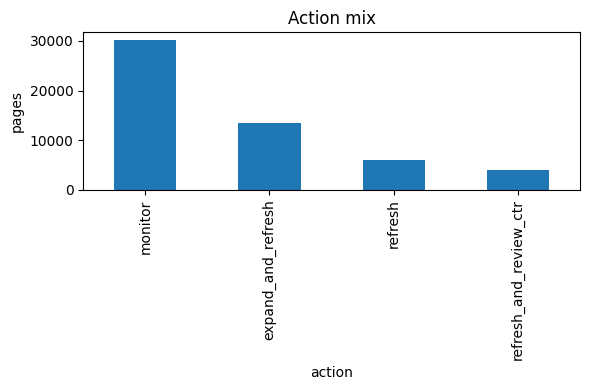

work/outputs/refresh_queue.csv           exists=True  size=6108844 bytes
work/outputs/summary.json                exists=True  size=417 bytes
work/outputs/charts/action_mix.svg       exists=True  size=22831 bytes

refresh_queue.csv: 53738 rows, columns = ['client_hash_id', 'content_hash_id', 'rf_score', 'action', 'reason_codes', 'confidence']
Columns matching forbidden raw-identifier patterns: None found


In [26]:
export_cols = ["client_hash_id", "content_hash_id", "rf_score", "action", "reason_codes", "confidence"]
queue[export_cols].to_csv("work/outputs/refresh_queue.csv", index=False)

summary = {
    "rows_scored": len(queue),
    "declining_rate": float(panel["is_declining"].mean()),
    "action_mix": queue["action"].value_counts().to_dict(),
    "confidence_mix": queue["confidence"].value_counts().to_dict(),
    "held_out_precision_at_50": 0.900,
    "held_out_precision_at_20": 0.900,
    "validation_method": "client_holdout, Feb 2026 features -> March 2026 label",
}
with open("work/outputs/summary.json", "w") as f:
    json.dump(summary, f, indent=2)

fig, ax = plt.subplots(figsize=(6, 4))
queue["action"].value_counts().plot(kind="bar", ax=ax)
ax.set_title("Action mix"); ax.set_ylabel("pages")
plt.tight_layout()
plt.savefig("work/outputs/charts/action_mix.svg")
plt.show()

for f in ["work/outputs/refresh_queue.csv", "work/outputs/summary.json", "work/outputs/charts/action_mix.svg"]:
    print(f"{f:<40} exists={os.path.exists(f)}  size={os.path.getsize(f) if os.path.exists(f) else 0} bytes")

check = pd.read_csv("work/outputs/refresh_queue.csv")
print(f"\nrefresh_queue.csv: {len(check)} rows, columns = {list(check.columns)}")
forbidden_terms = ["url", "domain", "query", "title", "client_name"]
flagged_cols = [c for c in check.columns if any(t in c.lower() for t in forbidden_terms)]
print(f"Columns matching forbidden raw-identifier patterns: {flagged_cols if flagged_cols else 'None found'}")

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.